# Task 3.3

1. Считать изображение с помощью OpenCV.
2. Выполнить линейную нормировку каждого канала R, G, B на диапазон `0..255`.
3. Найти интенсивности каналов для пикселя на пересечении строки `389` и столбца `625`.


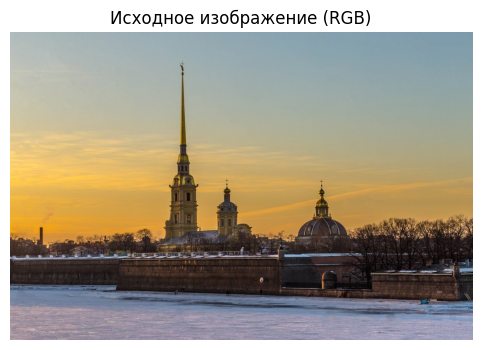

Размер изображения (H, W, C): (853, 1280, 3)


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1) Считываем изображение
image_bgr = cv2.imread('image.jpg')
if image_bgr is None:
    raise FileNotFoundError('Не удалось прочитать image.jpg')

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 4))
plt.imshow(image_rgb)
plt.title('Исходное изображение (RGB)')
plt.axis('off')
plt.show()

print('Размер изображения (H, W, C):', image_rgb.shape)

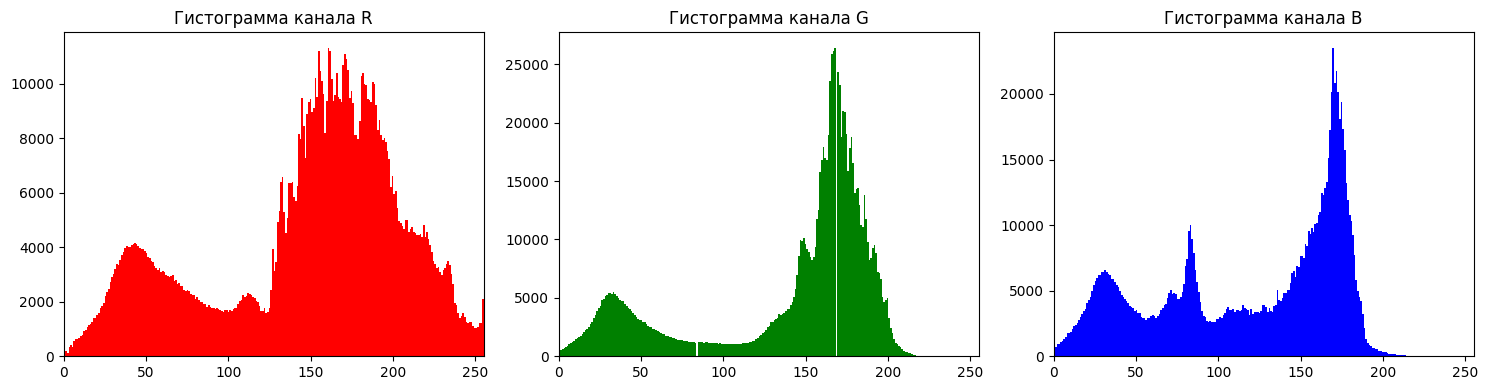

In [2]:
# 2) Линейная нормировка по каждому каналу в диапазон 0..255
normalized = image_rgb.astype(np.float32).copy()

for c in range(3):
    channel = normalized[:, :, c]
    c_min = channel.min()
    c_max = channel.max()
    if c_max > c_min:
        normalized[:, :, c] = (channel - c_min) / (c_max - c_min) * 255
    else:
        normalized[:, :, c] = 0

normalized = np.clip(normalized, 0, 255).astype(np.uint8)

# Гистограммы каналов после нормировки
colors = ('r', 'g', 'b')
labels = ('R', 'G', 'B')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (color, label) in enumerate(zip(colors, labels)):
    axes[i].hist(normalized[:, :, i].ravel(), bins=256, range=(0, 255), color=color)
    axes[i].set_title(f'Гистограмма канала {label}')
    axes[i].set_xlim(0, 255)

plt.tight_layout()
plt.show()

In [3]:
# 3) Значения интенсивности пикселя (строка 389, столбец 625)
row, col = 389, 625
R, G, B = normalized[row, col]

print(f'R = {R}')
print(f'G = {G}')
print(f'B = {B}')
print(f'Проверка (R, G, B): {normalized[row, col].tolist()}')

R = 199
G = 170
B = 103
Проверка (R, G, B): [199, 170, 103]
